# Store Sales – Time Series Forecasting
### Foundations of Data Science Project — Version 1 (Basic Baseline)

**Dataset:** Kaggle *Store Sales – Time Series Forecasting* (Corporación Favorita, Ecuador)
**Language / Tools:** Python, pandas, numpy, matplotlib, seaborn, scikit-learn

---

## Problem Statement
To develop a time series forecasting model for predicting future product sales across individual retail stores using historical sales data. The model aims to identify temporal patterns, trends, and seasonal variations while incorporating factors such as store characteristics, product families, promotions, holidays, events, transactions, and oil prices to improve the accuracy of sales predictions.

## About Version 1
This is the **basic version** of the project. The goal is **not** to build the perfect model, but to create a simple, working baseline that clearly shows the fundamental steps of a data science project. Improvements are planned for Version 2 (see the last section).

## Project Steps
1. Understand the dataset
2. Load and clean the data
3. Exploratory Data Analysis (EDA)
4. Basic feature engineering
5. Chronological train / validation split
6. Build a Random Forest model
7. Evaluate (RMSLE, MAE, RMSE)
8. Visualise predictions
9. Findings
10. Limitations and future work

## How to run this notebook in Google Colab
1. Open the **Files** panel (folder icon on the left) and **upload** the ZIP file `store-sales-time-series-forecasting.zip`. Do not unzip it manually.
2. If your ZIP file has a different name, change `ZIP_PATH` in the 3rd code cell.
3. Click **Runtime → Run all**. Training the model takes about **2–3 minutes**.


---
## Setup: Import Libraries and Extract the Data
We import the Python libraries we need and unzip the uploaded dataset.

- `pandas` / `numpy` – work with tables and numbers
- `matplotlib` / `seaborn` – draw graphs
- `scikit-learn` – the Random Forest model


In [1]:
# Import the libraries we need
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# Make graphs look clean
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 20)

In [2]:
# Path of the ZIP file you uploaded to Colab (left sidebar -> Files -> Upload)
ZIP_PATH = "store-sales-time-series-forecasting.zip"

# Extract all CSV files into a folder called "store_sales_data"
with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall("store_sales_data")

# Show the extracted files and their sizes
for name in sorted(os.listdir("store_sales_data")):
    size_mb = os.path.getsize(os.path.join("store_sales_data", name)) / (1024 * 1024)
    print(f"{name:25s} {size_mb:8.2f} MB")

holidays_events.csv           0.02 MB
oil.csv                       0.02 MB
sample_submission.csv         0.33 MB
stores.csv                    0.00 MB
test.csv                      0.97 MB
train.csv                   116.16 MB
transactions.csv              1.48 MB


---
## Step 1: Understand the Dataset
First, we load all 7 CSV files and look at their size, columns and data types before doing anything else.


In [3]:
# Load every CSV file into a pandas DataFrame
folder = "store_sales_data/"
train        = pd.read_csv(folder + "train.csv")
test         = pd.read_csv(folder + "test.csv")
stores       = pd.read_csv(folder + "stores.csv")
holidays     = pd.read_csv(folder + "holidays_events.csv")
oil          = pd.read_csv(folder + "oil.csv")
transactions = pd.read_csv(folder + "transactions.csv")
sample_sub   = pd.read_csv(folder + "sample_submission.csv")

# Keep all DataFrames in one dictionary so we can loop over them easily
files = {
    "train": train, "test": test, "stores": stores,
    "holidays_events": holidays, "oil": oil,
    "transactions": transactions, "sample_submission": sample_sub,
}

# Overview table: rows, columns and column names of each file
overview = pd.DataFrame({
    "file": list(files.keys()),
    "rows": [df.shape[0] for df in files.values()],
    "columns": [df.shape[1] for df in files.values()],
    "column names": [", ".join(df.columns) for df in files.values()],
})
display(overview)

                file     rows  columns                                               column names
0              train  3000888        6            id, date, store_nbr, family, sales, onpromotion
1               test    28512        5                   id, date, store_nbr, family, onpromotion
2             stores       54        5                      store_nbr, city, state, type, cluster
3    holidays_events      350        6  date, type, locale, locale_name, description, transferred
4                oil     1218        2                                           date, dcoilwtico
5       transactions    83488        3                              date, store_nbr, transactions
6  sample_submission    28512        2                                                  id, sales


In [4]:
# Look at the first rows and the data types of every file
for name, df in files.items():
    print("=" * 70)
    print(f"{name}  ->  {df.shape[0]:,} rows x {df.shape[1]} columns")
    display(df.head(3))
    print("Data types:")
    print(df.dtypes.to_string())

train  ->  3,000,888 rows x 6 columns
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
Data types:
id               int64
date               str
store_nbr        int64
family             str
sales          float64
onpromotion      int64
test  ->  28,512 rows x 5 columns
        id        date  store_nbr      family  onpromotion
0  3000888  2017-08-16          1  AUTOMOTIVE            0
1  3000889  2017-08-16          1   BABY CARE            0
2  3000890  2017-08-16          1      BEAUTY            2
Data types:
id             int64
date             str
store_nbr      int64
family           str
onpromotion    int64
stores  ->  54 rows x 5 columns
   store_nbr   city      state type  cluster
0          1  Quito  Pichincha    D       13
1          2  Quito  Pichincha    D       13
2          3  

### What does each file contain?

| File | Size (rows × columns) | What it contains | Important columns |
|---|---|---|---|
| `train.csv` | 3,000,888 × 6 | Daily sales history, 2013-01-01 to 2017-08-15 | `date`, `store_nbr`, `family`, `sales`, `onpromotion` |
| `test.csv` | 28,512 × 5 | The 16 days to be forecast (2017-08-16 to 2017-08-31). **No `sales` column.** | `date`, `store_nbr`, `family`, `onpromotion` |
| `stores.csv` | 54 × 5 | Information about each store | `store_nbr`, `city`, `state`, `type`, `cluster` |
| `holidays_events.csv` | 350 × 6 | Holidays and special events in Ecuador | `date`, `type`, `locale`, `description`, `transferred` |
| `oil.csv` | 1,218 × 2 | Daily oil price (Ecuador's economy depends on oil) | `date`, `dcoilwtico` |
| `transactions.csv` | 83,488 × 3 | Number of customer transactions per store per day (only up to 2017-08-15) | `date`, `store_nbr`, `transactions` |
| `sample_submission.csv` | 28,512 × 2 | Kaggle's required format for predictions | `id`, `sales` |

### Column meanings in `train.csv`
- **date** – the day of the sale
- **store_nbr** – which of the 54 stores
- **family** – product family (33 types, e.g. GROCERY I, BEVERAGES, PRODUCE)
- **sales** – total sales of that product family in that store on that day
- **onpromotion** – number of items of that family that were on promotion that day

So every row means: *"On this date, in this store, this product family sold this much."* There are 54 stores × 33 families = 1,782 separate daily sales series.

### Data types
Numbers (`id`, `store_nbr`, `sales`, `onpromotion`, ...) are already numeric. Text columns such as `date` and `family` are shown as `str` (in some Colab versions: `object`). The `date` column is still plain text, so we convert it to a real date in Step 2.

### Missing values (preview)
Only **`oil.csv`** has missing values (43 missing oil prices). Details in Step 2.

### Target variable: `sales`
`sales` is the value we want to predict. Reasons:
1. It is the column that is **missing in `test.csv`**; forecasting it for the future is exactly what the project asks for.
2. It is the **business quantity** a store needs to plan around (how many units will we sell?).
3. All other columns (date, store, promotions, ...) are *information that helps explain* sales.

### Which files will Version 1 use?
- `train.csv` and `test.csv` for the model.
- `transactions.csv` only for EDA, because it is **not available for the test period** (it ends on 2017-08-15), so the model cannot use it for future dates.
- `stores.csv`, `holidays_events.csv` and `oil.csv` are loaded and checked, but kept for **Version 2** to keep this version simple.


---
## Step 2: Load and Clean the Data
Basic preprocessing: convert dates, check missing values and duplicates, fix obvious missing values, and look at basic statistics. We do not need heavy cleaning for this dataset.


In [5]:
# 2.1 Convert the "date" column from text to a real datetime type
for df in [train, test, holidays, oil, transactions]:
    df["date"] = pd.to_datetime(df["date"])

print("train dates :", train["date"].min().date(), "to", train["date"].max().date())
print("test dates  :", test["date"].min().date(), "to", test["date"].max().date())
print("Number of stores  :", train["store_nbr"].nunique())
print("Number of families:", train["family"].nunique())

train dates : 2013-01-01 to 2017-08-15
test dates  : 2017-08-16 to 2017-08-31
Number of stores  : 54
Number of families: 33


In [6]:
# 2.2 Check missing values in every file
for name, df in files.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        print(f"{name:20s}: no missing values")
    else:
        print(f"{name:20s}: missing values -> {missing.to_dict()}")

# 2.3 Check duplicate rows in every file
print()
for name, df in files.items():
    print(f"{name:20s}: {df.duplicated().sum()} duplicate rows")

train               : no missing values
test                : no missing values
stores              : no missing values
holidays_events     : no missing values
oil                 : missing values -> {'dcoilwtico': 43}
transactions        : no missing values
sample_submission   : no missing values

train               : 0 duplicate rows
test                : 0 duplicate rows
stores              : 0 duplicate rows
holidays_events     : 0 duplicate rows
oil                 : 0 duplicate rows
transactions        : 0 duplicate rows
sample_submission   : 0 duplicate rows


In [7]:
# 2.4 Handle the missing oil prices
# Oil prices are not recorded on weekends/holidays, so we fill each gap with
# the previous known price (forward fill). The very first day has no previous
# price, so we use the next known price (backward fill).
oil["dcoilwtico"] = oil["dcoilwtico"].ffill().bfill()
print("Missing oil prices after filling:", oil["dcoilwtico"].isna().sum())

Missing oil prices after filling: 0


In [8]:
# 2.5 Basic statistics of the main columns
display(train[["sales", "onpromotion"]].describe().round(2))

# Extra checks on the target variable
print("Rows with zero sales     :", (train["sales"] == 0).sum(),
      f"({(train['sales'] == 0).mean() * 100:.1f}% of all rows)")
print("Rows with negative sales :", (train["sales"] < 0).sum())

# 2.6 Dataset information
print()
train.info()

            sales  onpromotion
count  3000888.00   3000888.00
mean       357.78         2.60
std       1102.00        12.22
min          0.00         0.00
25%          0.00         0.00
50%         11.00         0.00
75%        195.85         0.00
max     124717.00       741.00
Rows with zero sales     : 939130 (31.3% of all rows)
Rows with negative sales : 0

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 137.4 MB


In [9]:
# 2.7 Are there any dates missing from the training data?
all_days = pd.date_range(train["date"].min(), train["date"].max())
missing_days = all_days.difference(train["date"].unique())
print("Missing dates in train:", [d.date().isoformat() for d in missing_days])

Missing dates in train: ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']


### What we found
- **Dates:** now real datetime values. Training covers 2013-01-01 → 2017-08-15; the test period is the next 16 days.
- **Missing values:** only `oil.csv` had missing values (43 oil prices). We filled them with the previous known price, which is a reasonable and simple choice for a price that changes slowly. All other files are complete.
- **Duplicates:** none in any file.
- **Statistics of `sales`:** the **average is about 358**, but the **median is only 11** and the maximum is 124,717. This means sales are **heavily right-skewed**: most rows have small values and a few have very large values.
- **Zero sales:** **31.3%** of all rows have `sales = 0`. These are real values (for example, a product family a store did not sell yet), so we keep them.
- **No negative sales** exist.
- **Missing dates:** the training data skips **25 December** every year (2013–2016), which suggests stores were closed. This is normal for retail data and we leave it as it is.

The skewed `sales` values are the reason we will train the model on `log(1 + sales)` in Step 4.


---
## Step 3: Exploratory Data Analysis (EDA)
EDA means looking at the data with graphs to find patterns before building a model. For each graph, a short explanation of what we learn is given below it.


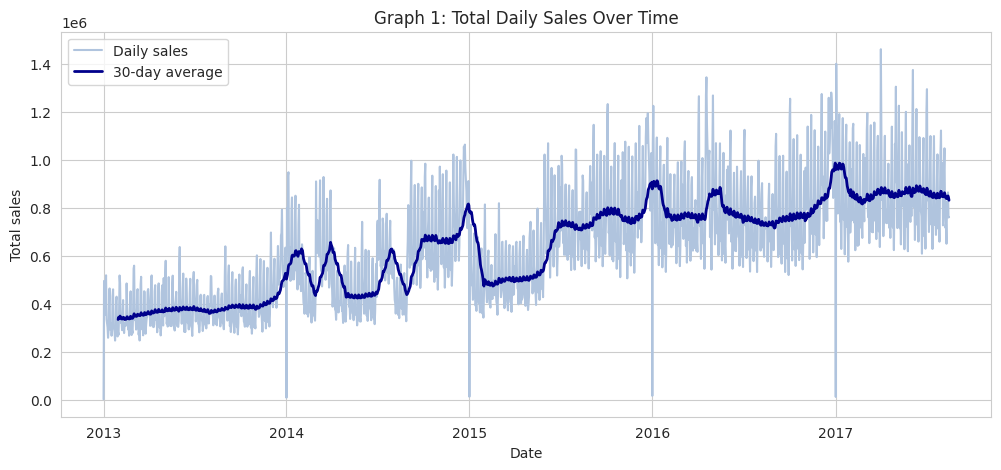

In [10]:
# Total sales of all stores and all families for each day
daily_sales = train.groupby("date")["sales"].sum()

# ---------- Graph 1: Sales over time ----------
plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values, color="lightsteelblue", label="Daily sales")
plt.plot(daily_sales.index, daily_sales.rolling(30).mean(), color="darkblue",
         linewidth=2, label="30-day average")
plt.title("Graph 1: Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total sales")
plt.legend()
plt.show()

**What we learn from Graph 1**
- **Upward trend:** average daily sales roughly **doubled** from about 386,000 in 2013 to about 856,000 in 2017.
- **Weekly pattern:** the light-blue line moves up and down constantly. This is a repeating weekly cycle (see Graph 7).
- **Year-end peaks:** the 30-day average rises around December/January each year.
- **Sudden drops to almost zero** appear on **1 January** every year (daily sales of only about 2,500 to 16,000). The stores appear to be almost closed on that day.
- **A clear dip in early 2015** is visible, after which sales recover. The data we use cannot explain it, so it is worth investigating in Version 2.

Because sales have a trend and repeating patterns, **date information** (year, month, day of week) should help the model.


date
Jan    609304
Feb    571895
Mar    627281
Apr    604454
May    609027
Jun    630111
Jul    666858
Aug    600521
Sep    645614
Oct    645810
Nov    669465
Dec    808565


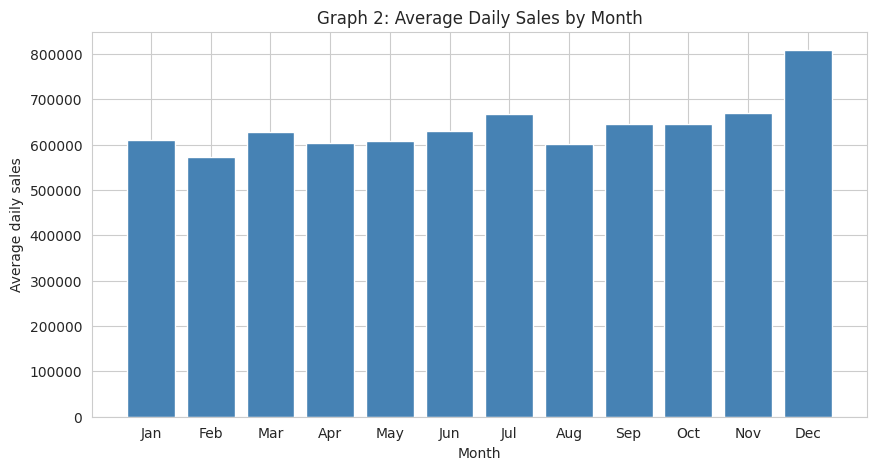

In [11]:
# ---------- Graph 2: Monthly sales pattern ----------
# Average daily sales for each calendar month (Jan-Dec), across all years
monthly_avg = daily_sales.groupby(daily_sales.index.month).mean()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 5))
plt.bar(month_names, monthly_avg.values, color="steelblue")
plt.title("Graph 2: Average Daily Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average daily sales")
plt.show()

print(monthly_avg.round(0).astype(int).rename(index=dict(enumerate(month_names, start=1))).to_string())

**What we learn from Graph 2**
- **December is clearly the strongest month** (about 809,000 per day), roughly **21% higher than November**, the next best month. This is likely the Christmas/holiday shopping season.
- **February is the weakest month** (about 572,000 per day).
- Other months stay in a fairly narrow range (about 600,000 – 670,000).

So **month** carries useful seasonal information and is a good feature.


Top 3 stores   : {44: 36979, 45: 32459, 47: 30344}
Bottom 3 stores: {35: 4572, 30: 4458, 32: 3545}
Best store sells 10.4 times more per day than the weakest store


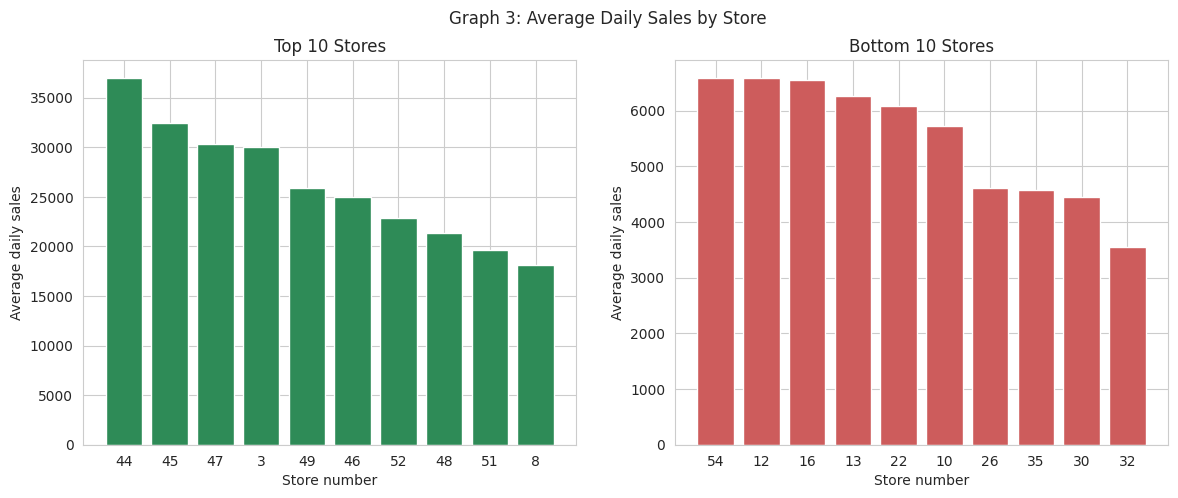

In [12]:
# ---------- Graph 3: Sales by store ----------
# Total sales of each store for each day
store_day = train.groupby(["store_nbr", "date"])["sales"].sum().reset_index()

# Some stores opened late, so we use the AVERAGE sales on days the store was selling
# (days with sales > 0). This is fairer than adding up all sales.
open_days = store_day[store_day["sales"] > 0]
store_avg = open_days.groupby("store_nbr")["sales"].mean().sort_values(ascending=False)

top10 = store_avg.head(10)
bottom10 = store_avg.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(top10.index.astype(str), top10.values, color="seagreen")
axes[0].set_title("Top 10 Stores")
axes[0].set_xlabel("Store number")
axes[0].set_ylabel("Average daily sales")
axes[1].bar(bottom10.index.astype(str), bottom10.values, color="indianred")
axes[1].set_title("Bottom 10 Stores")
axes[1].set_xlabel("Store number")
axes[1].set_ylabel("Average daily sales")
fig.suptitle("Graph 3: Average Daily Sales by Store")
plt.show()

print("Top 3 stores   :", top10.head(3).round(0).astype(int).to_dict())
print("Bottom 3 stores:", bottom10.tail(3).round(0).astype(int).to_dict())
print(f"Best store sells {top10.iloc[0] / bottom10.iloc[-1]:.1f} times more per day than the weakest store")

**What we learn from Graph 3**
- Store **44, 45 and 47** are the top performers (about 30,000 – 37,000 sales per day).
- Store **32, 30 and 35** are the weakest (about 3,500 – 4,600 per day).
- The best store sells about **10 times more per day** than the weakest one.

Stores differ a lot in size, so **`store_nbr` is an important feature**: the model must know which store it is predicting for.


Top 3 families share of all sales:
family
GROCERY I    32.0
BEVERAGES    20.2
PRODUCE      11.4
Top 3 together: 63.6%
Families with the lowest sales: ['BOOKS', 'BABY CARE', 'HOME APPLIANCES']


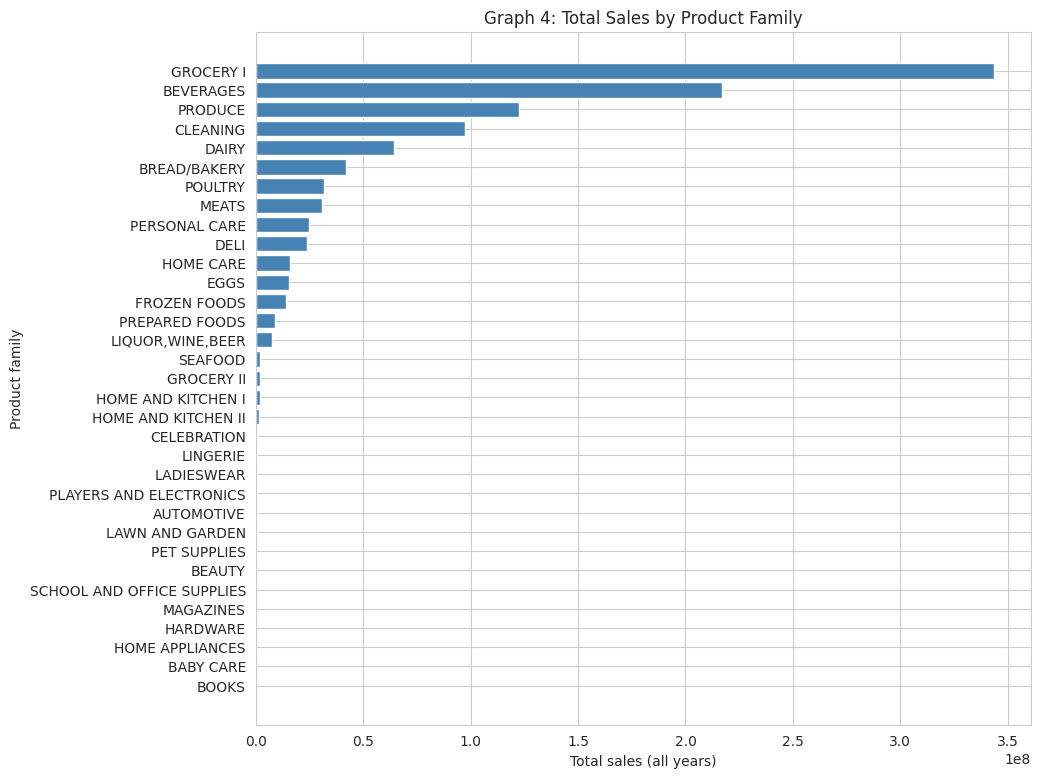

In [13]:
# ---------- Graph 4: Sales by product family ----------
family_total = train.groupby("family")["sales"].sum().sort_values()

plt.figure(figsize=(10, 9))
plt.barh(family_total.index, family_total.values, color="steelblue")
plt.title("Graph 4: Total Sales by Product Family")
plt.xlabel("Total sales (all years)")
plt.ylabel("Product family")
plt.show()

share = family_total / family_total.sum() * 100
print("Top 3 families share of all sales:")
print(share.tail(3).round(1).sort_values(ascending=False).to_string())
print(f"Top 3 together: {share.tail(3).sum():.1f}%")
print("Families with the lowest sales:", list(family_total.head(3).index))

**What we learn from Graph 4**
- Sales are **concentrated in a few families**: **GROCERY I (32.0%)**, **BEVERAGES (20.2%)** and **PRODUCE (11.4%)** together make up **63.6%** of all sales.
- Families such as **BOOKS, BABY CARE and HOME APPLIANCES** sell very little.

The product family changes the level of sales more than anything else, so the model needs the **family** as a feature (we will encode it as a number).


First date with any promotion: 2014-04-01
Average sales (all families):
promo_status
No promotion     117.9
On promotion    1137.7

Average sales (top 5 families):
promo_status  No promotion  On promotion
family                                  
BEVERAGES           1252.2        3215.5
CLEANING             806.6        1240.2
DAIRY                513.6         933.3
GROCERY I           1995.3        4411.0
PRODUCE             1149.7        2438.2

Correlation between onpromotion and sales: 0.428


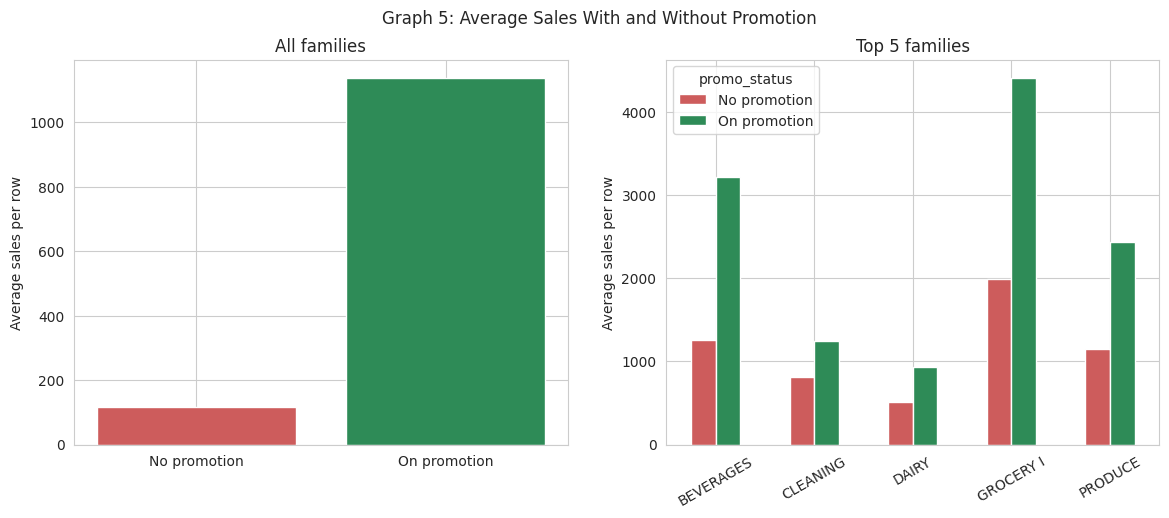

In [14]:
# ---------- Graph 5: Promotions vs sales ----------
# Promotion data only starts on 2014-04-01 (before that, onpromotion is always 0),
# so we compare only the period after that date to be fair.
print("First date with any promotion:", train.loc[train["onpromotion"] > 0, "date"].min().date())

promo_data = train[train["date"] >= "2014-04-01"].copy()
promo_data["promo_status"] = np.where(promo_data["onpromotion"] > 0, "On promotion", "No promotion")

# Panel 1: all families together
overall = promo_data.groupby("promo_status")["sales"].mean()

# Panel 2: top 5 families separately (to avoid mixing different product types)
top5_families = family_total.tail(5).index
family_promo = (promo_data[promo_data["family"].isin(top5_families)]
                .groupby(["family", "promo_status"])["sales"].mean().unstack())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(overall.index, overall.values, color=["indianred", "seagreen"])
axes[0].set_title("All families")
axes[0].set_ylabel("Average sales per row")
family_promo.plot(kind="bar", ax=axes[1], color=["indianred", "seagreen"])
axes[1].set_title("Top 5 families")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average sales per row")
axes[1].tick_params(axis="x", rotation=30)
fig.suptitle("Graph 5: Average Sales With and Without Promotion")
plt.show()

print("Average sales (all families):")
print(overall.round(1).to_string())
print()
print("Average sales (top 5 families):")
print(family_promo.round(1).to_string())
print()
print("Correlation between onpromotion and sales:", round(train["onpromotion"].corr(train["sales"]), 3))

**What we learn from Graph 5**
- Rows **on promotion** have a much higher average (about **1,138**) than rows **without promotion** (about **118**). The correlation between `onpromotion` and `sales` is **0.43**.
- Even **inside the same family**, promotion rows sell more: roughly **1.5 to 2.6 times** more for the top 5 families (for example, GROCERY I: about 1,995 without vs 4,411 with promotion).

⚠️ **Be careful:** this shows an **association, not proof that promotions cause the extra sales**. Promotions are more common on popular products and in bigger stores, which sell more anyway. Still, `onpromotion` is clearly a useful feature for prediction.


Correlation between transactions and sales: 0.837
Rows used: 83488


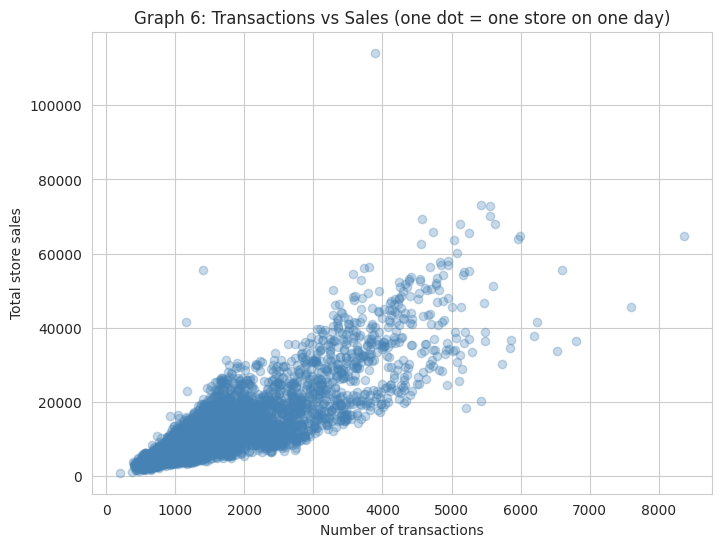

In [15]:
# ---------- Graph 6: Transactions vs sales ----------
# Join daily store sales with the number of customer transactions of that store and day
sales_trans = store_day.merge(transactions, on=["date", "store_nbr"])

# Plot a random sample of 5,000 points (plotting all of them would be too heavy)
sample = sales_trans.sample(5000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample["transactions"], sample["sales"], alpha=0.3, color="steelblue")
plt.title("Graph 6: Transactions vs Sales (one dot = one store on one day)")
plt.xlabel("Number of transactions")
plt.ylabel("Total store sales")
plt.show()

corr = sales_trans["transactions"].corr(sales_trans["sales"])
print(f"Correlation between transactions and sales: {corr:.3f}")
print("Rows used:", len(sales_trans))

**What we learn from Graph 6**
- The dots form a clear **upward pattern**: days with more customer transactions have higher sales. The correlation is **0.84** (strong positive).
- This is expected: more customers → more sales.

⚠️ `transactions` is **not available for the future test dates**, so we cannot use it directly in the Version 1 model. It would be a good variable to *forecast first* in a later version.


date
Mon    617543
Tue    569926
Wed    593245
Thu    505269
Fri    579574
Sat    772206
Sun    825218


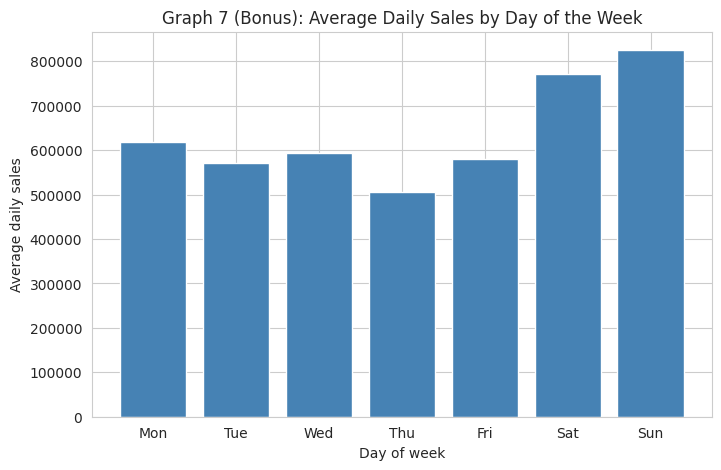

In [16]:
# ---------- Bonus Graph 7: Sales by day of the week ----------
# (We will use day_of_week as a feature, so it is worth checking)
weekday_avg = daily_sales.groupby(daily_sales.index.dayofweek).mean()
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(8, 5))
plt.bar(day_names, weekday_avg.values, color="steelblue")
plt.title("Graph 7 (Bonus): Average Daily Sales by Day of the Week")
plt.xlabel("Day of week")
plt.ylabel("Average daily sales")
plt.show()

print(weekday_avg.round(0).astype(int).rename(index=dict(enumerate(day_names))).to_string())

**What we learn from Graph 7 (Bonus)**
- **Sunday (about 825,000) and Saturday (about 772,000)** are the busiest days.
- **Thursday is the quietest** (about 505,000). Sunday sells about 1.6 times as much as Thursday.

This is the weekly pattern seen in Graph 1, so **`day_of_week` is a useful feature**.


---
## Step 4: Basic Feature Engineering
Machine learning models need **numbers**, so we convert our columns into simple numeric features.

**Features created (only the basic ones):**
| Feature | Meaning |
|---|---|
| `year`, `month`, `day`, `day_of_week` | Extracted from `date` (Monday = 0 … Sunday = 6) |
| `store_nbr` | Existing column (store number) |
| `onpromotion` | Existing column (items on promotion) |
| `family_code` | Product family converted to a number (0–32) |



In [17]:
# Give each product family a number (0 to 32). The same mapping is used for train and test.
family_map = {name: code for code, name in enumerate(sorted(train["family"].unique()))}

def add_features(df):
    """Create simple date features and encode the product family."""
    df = df.copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek      # Monday = 0 ... Sunday = 6
    df["family_code"] = df["family"].map(family_map)  # text -> number
    return df

train_fe = add_features(train)
test_fe = add_features(test)

# The columns the model is allowed to use
features = ["store_nbr", "family_code", "onpromotion", "year", "month", "day", "day_of_week"]

# Target: we predict log(1 + sales) instead of raw sales (explained below)
train_fe["log_sales"] = np.log1p(train_fe["sales"])

print("Features used:", features)
display(train_fe[["date"] + features + ["sales", "log_sales"]].head())
print("Family encoding (first 5):", dict(list(family_map.items())[:5]))

Features used: ['store_nbr', 'family_code', 'onpromotion', 'year', 'month', 'day', 'day_of_week']
        date  store_nbr  family_code  onpromotion  year  month  day  day_of_week  sales  log_sales
0 2013-01-01          1            0            0  2013      1    1            1    0.0        0.0
1 2013-01-01          1            1            0  2013      1    1            1    0.0        0.0
2 2013-01-01          1            2            0  2013      1    1            1    0.0        0.0
3 2013-01-01          1            3            0  2013      1    1            1    0.0        0.0
4 2013-01-01          1            4            0  2013      1    1            1    0.0        0.0
Family encoding (first 5): {'AUTOMOTIVE': 0, 'BABY CARE': 1, 'BEAUTY': 2, 'BEVERAGES': 3, 'BOOKS': 4}


### Why these choices?
- **Date features** let the model learn trend, seasonality and weekly patterns (Graphs 1, 2 and 7).
- **`family_code` (simple label encoding):** a model cannot read text like "GROCERY I", so each family gets a number. We use the *same* mapping for train and test data. We included `family` because Graph 4 shows it is the biggest driver of sales level, and the project would not work without it.
- **Why `log(1 + sales)`?** Sales are very skewed (median 11, maximum 124,717). The Kaggle metric, **RMSLE**, measures errors on the *logarithmic* scale. If we train the model directly on `log(1 + sales)`, we are training on the same scale that is used for scoring. After predicting, we convert back with the opposite function (`expm1`).


---
## Step 5: Basic Time-Series Split
We split by **time**: earlier dates for training, later dates for validation.

- **Training:** 2016-01-01 → 2017-07-30
- **Validation:** the **last 16 days** of the training file (2017-07-31 → 2017-08-15). This is the same length as the Kaggle test period (16 days), so it imitates the real forecasting task.


In [18]:
TRAIN_START = "2016-01-01"   # start of the training period (see note below)
SPLIT_DATE  = "2017-07-31"   # first day of the validation period

# Earlier dates -> training, later dates -> validation
train_part = train_fe[(train_fe["date"] >= TRAIN_START) & (train_fe["date"] < SPLIT_DATE)]
valid_part = train_fe[train_fe["date"] >= SPLIT_DATE]

X_train = train_part[features]
y_train = train_part["log_sales"]      # model learns log(1 + sales)
X_valid = valid_part[features]
y_valid = valid_part["sales"]          # we keep the real sales to evaluate

print("Training  :", train_part["date"].min().date(), "to", train_part["date"].max().date(),
      f"| {len(train_part):,} rows")
print("Validation:", valid_part["date"].min().date(), "to", valid_part["date"].max().date(),
      f"| {len(valid_part):,} rows ({valid_part['date'].nunique()} days)")
print("Test (Kaggle):", test["date"].min().date(), "to", test["date"].max().date(),
      f"| {test['date'].nunique()} days")

Training  : 2016-01-01 to 2017-07-30 | 1,026,432 rows
Validation: 2017-07-31 to 2017-08-15 | 28,512 rows (16 days)
Test (Kaggle): 2017-08-16 to 2017-08-31 | 16 days


### Why must time-series data be split chronologically?
1. **A real forecast always predicts the future from the past.** With a random split, the model would train on days that come *after* some of the validation days. It would "see the future", which is called **data leakage**.
2. **Neighbouring days are very similar.** In a random split, almost every validation day would have a near-identical training day right next to it, so the score would look much better than the model really is.
3. **A chronological split gives an honest score**, because the validation days are truly unseen and later in time.

### Note on the training period
We start training from 2016-01-01 (about 1 million rows) instead of using all 3 million rows from 2013. This keeps the model fast enough for Colab and keeps Version 1 simple. Using the full history is a possible improvement for Version 2.


---
## Step 6: Build a Basic Forecasting Model
We use a **Random Forest Regressor**.

**How it works (simple idea):** a Random Forest builds many decision trees. Each tree learns slightly different rules from the data, and the final prediction is the **average of all trees**. It is beginner-friendly because it works well with little tuning and handles numeric features like ours without any scaling.


In [19]:
# Random Forest = many decision trees whose predictions are averaged
model = RandomForestRegressor(
    n_estimators=50,        # number of trees
    min_samples_leaf=5,     # stops trees from memorising tiny groups of rows
    n_jobs=-1,              # use all CPU cores
    random_state=42,        # same results every time we run
)

model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


onpromotion    0.533
family_code    0.333
store_nbr      0.099
month          0.015
day            0.009
day_of_week    0.008
year           0.003


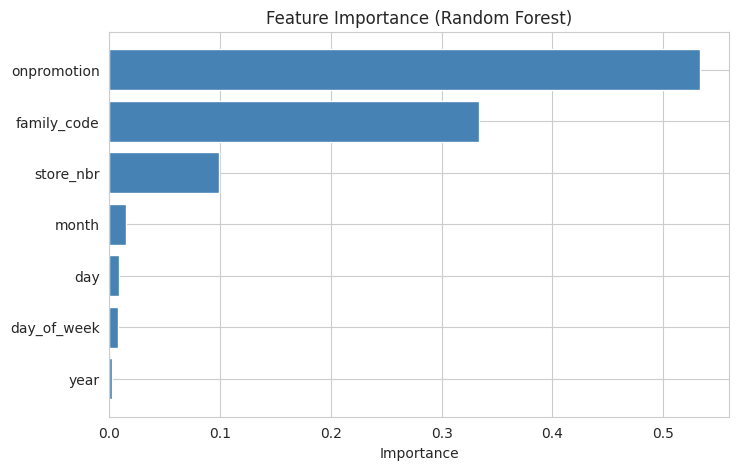

In [20]:
# Which features did the model find most useful?
importance = pd.Series(model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(importance.index, importance.values, color="steelblue")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

print(importance.sort_values(ascending=False).round(3).to_string())

### Feature importance
The importance chart shows how much each feature helped the model:
- **`onpromotion` (0.53)** and **`family_code` (0.33)** are the most important, followed by **`store_nbr` (0.10)**.
- Date features (`month`, `day`, `day_of_week`, `year`) have small importance (each 0.02 or less).

This matches our EDA: the **product family and store** decide the *size* of sales, while the date adds smaller adjustments. Note that `onpromotion` is probably so important partly because it also acts as a **hint about which store/family it is** (popular items get promoted more often), not only because promotions raise sales.


---
## Step 7: Evaluation
We evaluate on the validation period (the 16 days the model has never seen) using three metrics. The model predicts on the log scale, so we first convert predictions back to real sales units.

We also add a very simple **baseline** (always predicting the average training sales) so we can see whether the model is actually learning something.


In [21]:
# ---- Metric functions ----
def rmsle(actual, predicted):
    """Root Mean Squared Logarithmic Error (the Kaggle metric)."""
    return np.sqrt(np.mean((np.log1p(predicted) - np.log1p(actual)) ** 2))

def mae(actual, predicted):
    """Mean Absolute Error."""
    return np.mean(np.abs(actual - predicted))

def rmse(actual, predicted):
    """Root Mean Squared Error."""
    return np.sqrt(np.mean((actual - predicted) ** 2))

# ---- Predictions on the validation period ----
# The model predicts log(1 + sales), so we convert back with expm1.
# Sales cannot be negative, so we clip at 0.
pred_valid = np.expm1(model.predict(X_valid)).clip(min=0)

# ---- A very simple baseline for comparison: always predict the average training sales ----
baseline_pred = np.full(len(y_valid), train_part["sales"].mean())

# ---- Comparison table ----
results = pd.DataFrame({
    "RMSLE": [rmsle(y_valid, baseline_pred), rmsle(y_valid, pred_valid)],
    "MAE":   [mae(y_valid, baseline_pred),   mae(y_valid, pred_valid)],
    "RMSE":  [rmse(y_valid, baseline_pred),  rmse(y_valid, pred_valid)],
}, index=["Baseline (average sales)", "Random Forest (Version 1)"]).round(4)

display(results)

                            RMSLE       MAE       RMSE
Baseline (average sales)   3.5534  639.7724  1248.4059
Random Forest (Version 1)  0.4396   77.9234   290.8058


### The metrics in simple language
| Metric | Simple meaning | Better is |
|---|---|---|
| **RMSLE** | Average error measured on the *log scale*, which means it looks at **percentage-type mistakes** rather than raw unit mistakes. This is the official Kaggle metric. 0 would be perfect. | Lower |
| **MAE** | On average, how many **units** our prediction is away from the actual sales. | Lower |
| **RMSE** | Like MAE, but **big mistakes are punished more**. Always ≥ MAE. | Lower |

### Results (calculated from the real validation data)
| Model | RMSLE | MAE | RMSE |
|---|---|---|---|
| Baseline (average sales) | 3.5534 | 639.77 | 1248.41 |
| **Random Forest (Version 1)** | **0.4396** | **77.92** | **290.81** |

### Reading the table
- The Random Forest is **far better than the baseline** on all three metrics, so the model has learned real patterns.
- **MAE = 77.9:** on average the prediction is about 78 units away from actual sales for one store–family–day. This is mostly because sales are small for many rows (median 11) while a few families sell thousands.
- **RMSE (290.8) is much bigger than MAE (77.9):** a small number of very large mistakes exist, typically on high-volume rows where a small percentage error means many units.
- **RMSLE = 0.44** is our Version 1 score. We have only measured it on our own 16-day validation set, so we do not claim a Kaggle leaderboard score.


---
## Step 8: Prediction Visualisation
Three graphs: (8) actual vs predicted for individual rows, (9) actual vs predicted daily totals in the validation period, and (10) predicted sales over time, including the 16 test days.


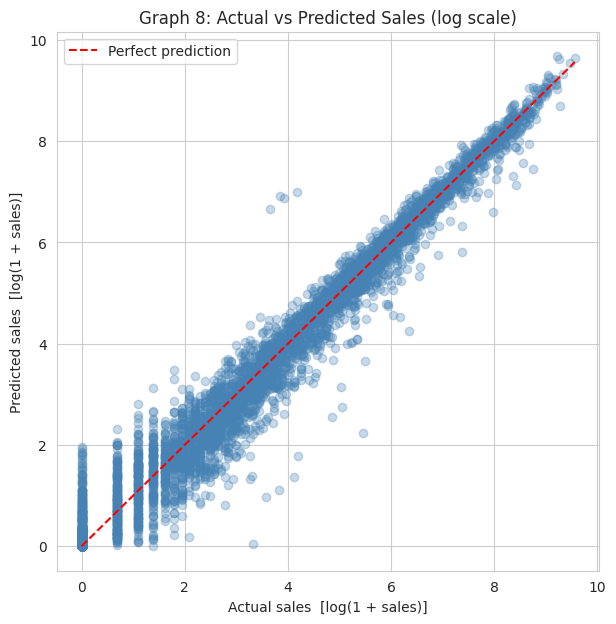

In [22]:
# Attach the predictions to the validation rows
valid_results = valid_part[["date", "store_nbr", "family", "sales"]].copy()
valid_results["predicted"] = pred_valid

# ---------- Graph 8: Actual vs Predicted (each dot = one store-family-day) ----------
sample = valid_results.sample(5000, random_state=42)

plt.figure(figsize=(7, 7))
plt.scatter(np.log1p(sample["sales"]), np.log1p(sample["predicted"]), alpha=0.3, color="steelblue")
max_val = np.log1p(sample["sales"]).max()
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect prediction")
plt.title("Graph 8: Actual vs Predicted Sales (log scale)")
plt.xlabel("Actual sales  [log(1 + sales)]")
plt.ylabel("Predicted sales  [log(1 + sales)]")
plt.legend()
plt.show()

Daily total error (%) -> mean: 0.5 | smallest: -15.5 | largest: 20.2


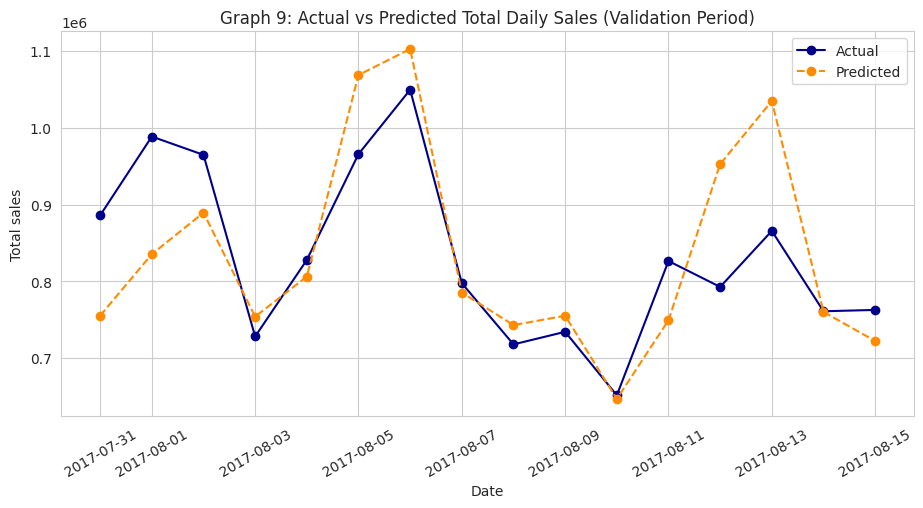

In [23]:
# ---------- Graph 9: Actual vs Predicted total daily sales (validation period) ----------
daily_valid = valid_results.groupby("date")[["sales", "predicted"]].sum()

plt.figure(figsize=(11, 5))
plt.plot(daily_valid.index, daily_valid["sales"], marker="o", color="darkblue", label="Actual")
plt.plot(daily_valid.index, daily_valid["predicted"], marker="o", color="darkorange",
         linestyle="--", label="Predicted")
plt.title("Graph 9: Actual vs Predicted Total Daily Sales (Validation Period)")
plt.xlabel("Date")
plt.ylabel("Total sales")
plt.xticks(rotation=30)
plt.legend()
plt.show()

error_pct = ((daily_valid["predicted"] - daily_valid["sales"]) / daily_valid["sales"] * 100)
print("Daily total error (%) -> mean:", round(error_pct.mean(), 1),
      "| smallest:", round(error_pct.min(), 1), "| largest:", round(error_pct.max(), 1))

Forecasted total sales for the 16 test days: 12,770,169


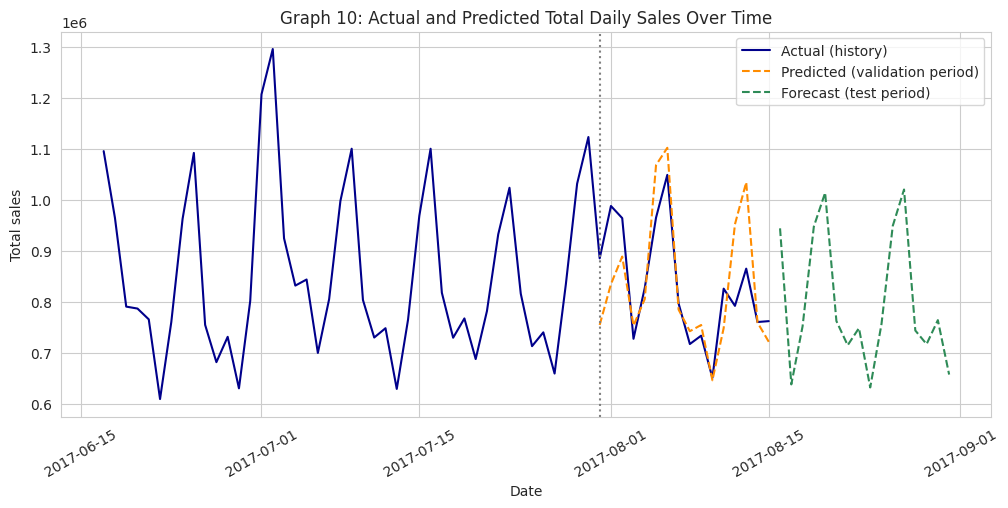

In [24]:
# ---------- Graph 10: Predicted sales over time (including the Kaggle test period) ----------
# Predict the 16 test days (2017-08-16 to 2017-08-31). Actual sales for these days are NOT available.
test_pred = np.expm1(model.predict(test_fe[features])).clip(min=0)
daily_test = test_fe.assign(predicted=test_pred).groupby("date")["predicted"].sum()

# Last 60 days of real history
recent_actual = daily_sales.tail(60)

plt.figure(figsize=(12, 5))
plt.plot(recent_actual.index, recent_actual.values, color="darkblue", label="Actual (history)")
plt.plot(daily_valid.index, daily_valid["predicted"], color="darkorange", linestyle="--",
         label="Predicted (validation period)")
plt.plot(daily_test.index, daily_test.values, color="seagreen", linestyle="--",
         label="Forecast (test period)")
plt.axvline(pd.Timestamp(SPLIT_DATE), color="grey", linestyle=":")
plt.title("Graph 10: Actual and Predicted Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total sales")
plt.xticks(rotation=30)
plt.legend()
plt.show()

print("Forecasted total sales for the 16 test days:", f"{daily_test.sum():,.0f}")

### What we learn from the prediction graphs
**Graph 8 – Actual vs Predicted (log scale):**
- The dots lie **close to the red diagonal line**, which means predictions are close to actual values for most rows.
- Dots are more spread out at the **bottom left**, where actual sales are 0 to a few units. The model finds low and zero sales hard to predict exactly.

**Graph 9 – Total daily sales (validation period):**
- The model **follows the weekly up-and-down pattern** well. The average daily error is only **+0.5%** (a tiny over-prediction overall).
- But on individual days the error ranges from **−15.5% to +20.2%**. It **under-predicts** the first days (31 July – 2 August) and **over-predicts** 12–13 August.
- This shows what the model is missing: it knows the *typical* weekday level but not what is special about particular days of the month.

**Graph 10 – Predicted sales over time:**
- The forecast for the 16 test days (green) continues the **same weekly pattern** as the history, with peaks on weekends and lows on weekdays.
- We **cannot check** the test forecast, because actual test sales are not provided. It is shown only to demonstrate how the model is used for forecasting.
- The history shows extra-high days near the start of the month and around the middle and end of the month. Our simple features do not capture this well (an idea for Version 2).

*(The optional last cell in this step saves the predictions as `submission.csv` in the Kaggle format.)*


In [25]:
# (Optional) Save the forecasts in the Kaggle submission format
submission = pd.DataFrame({"id": test["id"], "sales": test_pred})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
display(submission.head())

(28512, 2)
        id        sales
0  3000888     4.192053
1  3000889     0.000000
2  3000890     4.235526
3  3000891  2334.107586
4  3000892     0.595885


---
## Step 9: Basic Findings
The cell below prints the main numbers used in the findings.


In [26]:
# Print all key numbers in one place (used in the findings below)
print("DATASET")
print(f"  Training rows            : {len(train):,}")
print(f"  Stores / families        : {train['store_nbr'].nunique()} / {train['family'].nunique()}")
print(f"  Zero-sales rows          : {(train['sales'] == 0).mean() * 100:.1f}%")
print(f"  Top-3 family share       : {share.tail(3).sum():.1f}%")
print(f"  Corr(transactions,sales) : {corr:.3f}")
print()
print("MODEL")
print("  Random Forest, 50 trees, 7 features")
display(results)

DATASET
  Training rows            : 3,000,888
  Stores / families        : 54 / 33
  Zero-sales rows          : 31.3%
  Top-3 family share       : 63.6%
  Corr(transactions,sales) : 0.837

MODEL
  Random Forest, 50 trees, 7 features
                            RMSLE       MAE       RMSE
Baseline (average sales)   3.5534  639.7724  1248.4059
Random Forest (Version 1)  0.4396   77.9234   290.8058


### Dataset Findings
1. **Large and complete data:** 3,000,888 training rows covering 54 stores and 33 product families from 2013-01-01 to 2017-08-15. Only the oil prices had missing values (43), and there are no duplicate rows.
2. **Growth and seasonality:** average daily sales grew from about 386,000 (2013) to about 856,000 (2017). December is the strongest month and Saturday/Sunday are the strongest weekdays.
3. **Sales are concentrated and skewed:** GROCERY I, BEVERAGES and PRODUCE make up 63.6% of sales. 31.3% of rows have zero sales, and the median row sells only 11 units.
4. **Stores differ a lot:** the best store (44) sells about 10 times more per day than the weakest one (32).
5. **Promotions and transactions are associated with higher sales:** the correlation of sales with transactions is 0.84, and rows on promotion sell clearly more, though this does not prove cause and effect.

### Model Findings
| Item | Result |
|---|---|
| Model used | Random Forest Regressor (50 trees, 7 features) |
| Training period | 2016-01-01 to 2017-07-30 (1,026,432 rows) |
| Validation period | 2017-07-31 to 2017-08-15 (16 days, 28,512 rows) |
| **RMSLE** | **0.4396** (baseline: 3.5534) |
| **MAE** | **77.92** (baseline: 639.77) |
| **RMSE** | **290.81** (baseline: 1248.41) |

- The model is **much better than the simple baseline** and captures the weekly pattern and the size differences between stores and families.
- It is **less accurate on single days** (daily total error from −15.5% to +20.2%) and on rows with very low sales.
- `onpromotion`, `family_code` and `store_nbr` were the most important features.

### Business Findings: how forecasting helps a retail company
- **Inventory planning:** knowing how much each store will sell of each product family in the coming days helps order the right quantity from suppliers. This avoids both empty shelves and too much stock.
- **Stock management:** forecasts can guide how stock is distributed between stores. For example, high-volume stores and the Saturday–Sunday peak need more stock than slow stores and weekdays. Perishable families (such as PRODUCE and DAIRY) especially benefit from avoiding over-ordering.
- **Promotions:** since promoted rows are associated with higher sales, a forecast can help plan *when* and *on which products* to run promotions, and prepare extra stock for them.
- **Demand planning:** predicted seasonal peaks (such as December) help plan staff, deliveries and budgets weeks ahead.


---
## Step 10: Version 1 Summary, Limitations and Next Steps
This notebook is the **basic baseline (Version 1)**. It works, but it is intentionally simple.

### Limitations of Version 1
1. **Limited features:** only 7 features. `stores.csv` (city, store type, cluster), holidays/events and oil prices are not used.
2. **Basic model:** one Random Forest with default-style settings, and no comparison with other models.
3. **No time-series information in the features:** the model does not know what sales were yesterday or last week.
4. **No lag features** (e.g. sales 7 days ago, 14 days ago).
5. **No rolling averages** (e.g. average of the last 7 or 28 days).
6. **Limited holiday/event integration:** holidays and special events are ignored. Extra-high days such as the start/middle/end of the month are not captured.
7. **No hyperparameter tuning:** the number of trees and other settings were chosen by hand and never optimised.
8. **Partial history:** training starts in 2016 to save time, so earlier years are not used.
9. **Short validation window:** only 16 days were used to judge the model, so the result can change with other periods.
10. **Zero sales and store openings:** some stores/families have zero sales because they had not opened yet or did not sell the product. The model does not handle this specially.
11. **Forecast not retrained:** the test forecast uses the model trained only until 2017-07-30. It was not retrained with the validation days.
12. **No Kaggle score:** we did not submit to Kaggle, so we only know our own validation score.

### Suggestions for Improvement (Version 2)
| Idea | What to do | Fixes limitation |
|---|---|---|
| Lag features | Add sales from 7, 14 and 28 days earlier for the same store and family | 3, 4 |
| Rolling averages | Add the average sales of the last 7 and 28 days | 3, 5 |
| Holidays and events | Merge `holidays_events.csv` (flag national, regional and local holidays; handle `transferred`) | 6 |
| Store information | Merge `stores.csv` (type, cluster, city) | 1 |
| Oil prices | Merge the cleaned oil price as a feature | 1 |
| Payday features | Add "days since month start / until month end" | 6 |
| Transactions | Forecast transactions first, or use their past averages | 1 |
| Full history and retraining | Use all years and retrain on train + validation before forecasting the test period | 8, 11 |
| Better evaluation | Validate on several time windows instead of one | 9 |
| Hyperparameter tuning | Try different tree counts, depths and leaf sizes | 7 |
| Other models | Compare with Linear Regression, XGBoost or LightGBM | 2 |
| Zero-sales handling | Handle stores that were not yet open | 10 |

### Conclusion
We built a complete and honest baseline: we inspected and cleaned the data, explored it, created basic features, split the data in time order, trained a Random Forest and evaluated it with RMSLE, MAE and RMSE. The model scores **RMSLE 0.4396** on our validation period, far better than the baseline, and it gives a clear starting point to improve in Version 2.
